**05_categorical_embeddings.ipynb: Multimodal Categorical Entity Embeddings & Ablation Study**

**Multimodal Financial Fraud / Risk Detector**  
This notebook implements **Phase 6: Categorical Entity Embeddings**.  
While Phase 5 evaluated a purely numerical MLP, this phase unlocks the full tabular dataset by learning dense vector representations (`nn.Embedding`) for all **49 categorical features** (`ProductCD`, `card1-6`, `DeviceInfo`, `P_emaildomain`, etc.) and fusing them with normalized numerical features.

```
HYBRID EMBEDDING PIPELINE
                    IEEE-CIS Transaction
                           │
             ┌─────────────┴─────────────┐
             │                           │
       381 Numerical                49 Categorical
             │                           │
       BatchNorm /                 Embedding tables
       normalized input            (one per category)
             │                           │
             │                     embedding vectors
             │                           │
             └─────────────┬─────────────┘
                           │
                      Concatenate
                           │
                    Dense MLP
                  256 → 128 → 64
                           │
                    Fraud Logit
                           │
                 sigmoid at inference
                           │
                  Fraud Probability
```

**Core Scientific Question**:  
*Do learned categorical entity embeddings provide measurable predictive value over numerical-only architectures, and can they bridge the performance gap with tree-based gradient boosting (XGBoost)?*


**1. Load Existing Processed Data**

We import required libraries and load the IEEE-CIS transaction and identity data using our memory-optimized pipeline from `src.preprocessing`.


In [1]:
import sys
from pathlib import Path

# Add project root to sys.path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from src.preprocessing import (
    load_and_merge_data,
    temporal_train_val_test_split,
    TabularPreprocessor
)
from src.dataset import FraudDataset, create_dataloaders
from src.model import HybridFraudDetector, compute_embedding_dim
from src.train import train_model, evaluate_dataloader
from src.evaluate import (
    compute_fraud_metrics,
    evaluate_thresholds,
    find_optimal_threshold,
    plot_confusion_matrix,
    plot_pr_curves,
    plot_roc_curves
)

# Plotting aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 120

FIG_DIR = PROJECT_ROOT / "results" / "figures"
METRICS_DIR = PROJECT_ROOT / "results" / "metrics"
MODELS_DIR = PROJECT_ROOT / "models"
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch Version: {torch.__version__} | Active Device: {device}")

NROWS = 100_000
data_dir = PROJECT_ROOT / "data" / "raw"
print(f"Loading merged dataset (nrows={NROWS})...")
df = load_and_merge_data(data_dir=data_dir, split="train", nrows=NROWS, reduce_memory=True, verbose=True)


2026-10-02 11:39:03,586 - INFO - Loading train_transaction.csv (nrows=100000)...


PyTorch Version: 2.14.0+cpu | Active Device: cpu
Loading merged dataset (nrows=100000)...


2026-10-02 11:39:08,809 - INFO - Memory reduced from 300.60 MB to 155.16 MB (48.4% reduction)


2026-10-02 11:39:08,811 - INFO - Successfully loaded train_transaction.csv with shape: (100000, 394)


2026-10-02 11:39:08,812 - INFO - Loading train_identity.csv (nrows=100000)...


2026-10-02 11:39:09,223 - INFO - Memory reduced from 31.28 MB to 22.13 MB (29.3% reduction)


2026-10-02 11:39:09,224 - INFO - Successfully loaded train_identity.csv with shape: (100000, 41)


2026-10-02 11:39:09,235 - INFO - Merging train transaction (100000 rows) and identity (100000 rows) on TransactionID...


2026-10-02 11:39:09,526 - INFO - Merged dataset shape: (100000, 434). Identity match rate: 40.28% (40283/100000)


**2 & 3. Load Preprocessing Artifacts & Verify All 49 Categorical Columns**

We execute the strict 70/15/15 chronological temporal split and transform features using `TabularPreprocessor` (fitted strictly on `train_df`).  
We inspect the extracted categorical vocabulary sizes across all 49 categorical features.


In [2]:
# 1. Chronological Split
train_df, val_df, test_df = temporal_train_val_test_split(df, val_ratio=0.15, test_ratio=0.15)

# 2. Fit Preprocessor strictly on train
preprocessor = TabularPreprocessor(min_freq=10, log_transform_amt=True, drop_zero_variance=True)
preprocessor.fit(train_df)

# 3. Transform splits
X_num_train, X_cat_train, y_train = preprocessor.transform(train_df)
X_num_val, X_cat_val, y_val = preprocessor.transform(val_df)
X_num_test, X_cat_test, y_test = preprocessor.transform(test_df)

cat_feature_names = preprocessor.fitted_categorical_cols_
cat_vocab_sizes = [preprocessor.vocab_sizes_[col] for col in cat_feature_names]
num_features = X_num_train.shape[1]

print("=== Feature Representation Summary ===")
print(f"Numerical Features:   {num_features} dimensions")
print(f"Categorical Features: {len(cat_feature_names)} features")
print(f"Sample Categorical Vocabularies:")
for col, v_size in list(zip(cat_feature_names, cat_vocab_sizes))[:10]:
    print(f"  {col:15s}: {v_size:4d} unique tokens (including <UNK>/<MISSING>)")

print(f"\nArray Dimensions:")
print(f"  Train: Numerical {X_num_train.shape}, Categorical {X_cat_train.shape}, Labels {y_train.shape}")
print(f"  Val:   Numerical {X_num_val.shape}, Categorical {X_cat_val.shape}, Labels {y_val.shape}")
print(f"  Test:  Numerical {X_num_test.shape}, Categorical {X_cat_test.shape}, Labels {y_test.shape}")


2026-10-02 11:39:09,707 - INFO - Sorting dataset by 'TransactionDT' for strict chronological temporal splitting...


2026-10-02 11:39:10,139 - INFO - Temporal Split Completed Successfully:


2026-10-02 11:39:10,145 - INFO -   [TRAIN] Rows: 70,000 (70.0%) | DT: [86,400 - 1,564,844] (~17.1 days), Frauds=1879 (2.68%)


2026-10-02 11:39:10,147 - INFO -   [VAL] Rows: 15,000 (15.0%) | DT: [1,564,850 - 1,804,023] (~2.8 days), Frauds=377 (2.51%)


2026-10-02 11:39:10,149 - INFO -   [TEST] Rows: 15,000 (15.0%) | DT: [1,804,027 - 2,006,364] (~2.3 days), Frauds=305 (2.03%)


...

2026-10-02 11:39:10,889 - INFO - Dropping 1 zero-variance numerical features: ['V107']


2026-10-02 11:39:10,890 - INFO - Selected 381 numerical and 49 categorical features.


2026-10-02 11:39:11,943 - INFO - Successfully fitted StandardScaler on imputed training numericals.


2026-10-02 11:39:12,649 - INFO - Built vocabularies for 49 categorical features (min_freq=10).


=== Feature Representation Summary ===
Numerical Features:   381 dimensions
Categorical Features: 49 features
Sample Categorical Vocabularies:
  ProductCD      :    6 unique tokens (including <UNK>/<MISSING>)
  card1          :  847 unique tokens (including <UNK>/<MISSING>)
  card2          :  385 unique tokens (including <UNK>/<MISSING>)
  card3          :   26 unique tokens (including <UNK>/<MISSING>)
  card4          :    5 unique tokens (including <UNK>/<MISSING>)
  card5          :   44 unique tokens (including <UNK>/<MISSING>)
  card6          :    3 unique tokens (including <UNK>/<MISSING>)
  addr1          :   88 unique tokens (including <UNK>/<MISSING>)
  addr2          :   12 unique tokens (including <UNK>/<MISSING>)
  P_emaildomain  :   54 unique tokens (including <UNK>/<MISSING>)

Array Dimensions:
  Train: Numerical (70000, 381), Categorical (70000, 49), Labels (70000,)
  Val:   Numerical (15000, 381), Categorical (15000, 49), Labels (15000,)
  Test:  Numerical (15000, 381

**4 & 5. Define Embedding Dimensions & Embedding Module**

For each categorical feature, the embedding dimension is dynamically calculated using the standard empirical rule:
$$d_i = \min\left(50, \max\left(4, \left\lceil 6 \times \sqrt[4]{\text{vocab\_size}_i} \right\rceil\right)\right)$$
This allocates higher representational capacity to high-cardinality features (`DeviceInfo`, `card1`, `addr1`) while keeping low-cardinality features (`ProductCD`, `card4`, `DeviceType`) compact.


In [3]:
# Compute embedding dimensions
embedding_dims = [compute_embedding_dim(v) for v in cat_vocab_sizes]
total_embedding_dim = sum(embedding_dims)

emb_summary_df = pd.DataFrame({
    "Categorical_Feature": cat_feature_names,
    "Vocab_Size": cat_vocab_sizes,
    "Embedding_Dim": embedding_dims
}).sort_values("Vocab_Size", ascending=False)

print("=== Top 15 Categorical Features by Vocabulary & Embedding Dimension ===")
print(emb_summary_df.head(15).to_string(index=False))
print(f"\nTotal Fused Latent Dimension: {num_features} (Numerical) + {total_embedding_dim} (Embeddings) = {num_features + total_embedding_dim} Total Inputs to Dense MLP")


=== Top 15 Categorical Features by Vocabulary & Embedding Dimension ===
Categorical_Feature  Vocab_Size  Embedding_Dim
              card1         847             32
              card2         385             27
              id_19         125             20
              id_20          88             18
              addr1          88             18
         DeviceInfo          82             18
              id_30          61             17
      P_emaildomain          54             16
              id_31          52             16
              id_33          48             16
              card5          44             15
      R_emaildomain          41             15
              card3          26             14
              id_13          23             13
              id_26          20             13

Total Fused Latent Dimension: 381 (Numerical) + 568 (Embeddings) = 949 Total Inputs to Dense MLP


**6 & 7. Combine Numerical + Categorical Model & Initialize DataLoaders**

We wrap features into `FraudDataset` instances and instantiate `HybridFraudDetector` from `src.model`:
- Dense input dimension: $381 + \sum d_i = 381 + 457 = 838$
- Layer architecture: `Linear(838 → 256) → BatchNorm1d → ReLU → Dropout(0.3) → Linear(256 → 128) → BatchNorm1d → ReLU → Dropout(0.3) → Linear(128 → 64) → BatchNorm1d → ReLU → Dropout(0.2) → Linear(64 → 1)`


In [4]:
BATCH_SIZE = 512

train_dataset = FraudDataset(X_num_train, X_cat_train, y_train)
val_dataset = FraudDataset(X_num_val, X_cat_val, y_val)
test_dataset = FraudDataset(X_num_test, X_cat_test, y_test)

loaders = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

# Positional loss weighting tensor for Experiment 6B
imbalance_ratio = float((y_train == 0).sum() / (y_train == 1).sum())
pos_weight_tensor = torch.tensor([imbalance_ratio], dtype=torch.float32).to(device)
print(f"Class Imbalance Ratio (Neg/Pos): {imbalance_ratio:.2f}")


2026-10-02 11:39:14,856 - INFO - Created 'train' DataLoader: 70,000 samples, 137 batches (batch_size=512)


2026-10-02 11:39:14,856 - INFO - Created 'val' DataLoader: 15,000 samples, 30 batches (batch_size=512)


2026-10-02 11:39:14,857 - INFO - Created 'test' DataLoader: 15,000 samples, 30 batches (batch_size=512)


Class Imbalance Ratio (Neg/Pos): 36.25


**8. Experiment 6A: Hybrid Network + Standard BCE**

We train the hybrid network using unweighted `nn.BCEWithLogitsLoss()`.  
Validation PR-AUC is monitored after each epoch with early stopping patience of 5 epochs.


In [5]:
print("=== Running Experiment 6A: Hybrid Network + Standard BCE ===")
torch.manual_seed(42)
np.random.seed(42)

model_6a = HybridFraudDetector(
    num_numerical_features=num_features,
    categorical_cardinalities=cat_vocab_sizes,
    embedding_dims=embedding_dims
).to(device)

criterion_6a = nn.BCEWithLogitsLoss()
optimizer_6a = AdamW(model_6a.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_6a = ReduceLROnPlateau(optimizer_6a, mode="max", factor=0.5, patience=2)

checkpoint_6a = MODELS_DIR / "pytorch_hybrid_standard_bce.pt"

model_6a, history_6a = train_model(
    model=model_6a,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_6a,
    optimizer=optimizer_6a,
    scheduler=scheduler_6a,
    num_epochs=12,
    patience=5,
    device=device,
    checkpoint_path=checkpoint_6a,
    monitor_metric="PR-AUC",
    verbose=True
)

# Evaluate on Validation & Test
_, val_metrics_6a, y_val_true, y_val_prob_6a = evaluate_dataloader(model_6a, val_loader, criterion_6a, device)
_, _, y_test_true, y_test_prob_6a = evaluate_dataloader(model_6a, test_loader, criterion_6a, device)

# Find optimal threshold on validation set
opt_thresh_6a, _ = find_optimal_threshold(y_val_true, y_val_prob_6a, metric="F1")
test_metrics_6a = compute_fraud_metrics(y_test_true, y_test_prob_6a, threshold=opt_thresh_6a)

print(f"\nExperiment 6A Results:")
print(f"  Validation: PR-AUC={val_metrics_6a['PR-AUC']:.4f}, ROC-AUC={val_metrics_6a['ROC-AUC']:.4f}, Opt Threshold={opt_thresh_6a:.2f}")
print(f"  Test:       PR-AUC={test_metrics_6a['PR-AUC']:.4f}, ROC-AUC={test_metrics_6a['ROC-AUC']:.4f}, F1={test_metrics_6a['F1']:.4f}, Recall={test_metrics_6a['Recall']:.4f}, Precision={test_metrics_6a['Precision']:.4f}")


=== Running Experiment 6A: Hybrid Network + Standard BCE ===


2026-10-02 11:39:17,022 - INFO - Starting training for up to 12 epochs on cpu (Monitoring: PR-AUC)...


2026-10-02 11:39:22,871 - INFO - Epoch  1/12 | Train Loss: 0.2540 | Val Loss: 0.1041 | Val PR-AUC: 0.4463 | Val ROC-AUC: 0.8726 | Val F1: 0.2756 | LR: 1.00e-03


2026-10-02 11:39:22,872 - INFO - Validation metric improved (None -> 0.4463). Saving checkpoint...


2026-10-02 11:39:28,202 - INFO - Epoch  2/12 | Train Loss: 0.0969 | Val Loss: 0.0767 | Val PR-AUC: 0.5045 | Val ROC-AUC: 0.8909 | Val F1: 0.4107 | LR: 1.00e-03


...

2026-10-02 11:40:17,174 - INFO - EarlyStopping counter: 1/5 (Best: 0.5772 at Epoch 10)


2026-10-02 11:40:23,200 - INFO - Epoch 12/12 | Train Loss: 0.0348 | Val Loss: 0.0772 | Val PR-AUC: 0.5531 | Val ROC-AUC: 0.8743 | Val F1: 0.5872 | LR: 5.00e-04


2026-10-02 11:40:23,201 - INFO - EarlyStopping counter: 2/5 (Best: 0.5772 at Epoch 10)


2026-10-02 11:40:23,208 - INFO - Restored best model weights from epoch 10 with PR-AUC = 0.5772



Experiment 6A Results:
  Validation: PR-AUC=0.5772, ROC-AUC=0.8785, Opt Threshold=0.20
  Test:       PR-AUC=0.4623, ROC-AUC=0.8702, F1=0.4544, Recall=0.4328, Precision=0.4783


**9. Experiment 6B: Hybrid Network + Imbalance-Weighted BCE**

We train the hybrid network with `pos_weight = 36.3` applied to the fraud loss term to directly penalize missed fraudulent transactions.


In [6]:
print("=== Running Experiment 6B: Hybrid Network + Imbalance-Weighted BCE ===")
torch.manual_seed(42)
np.random.seed(42)

model_6b = HybridFraudDetector(
    num_numerical_features=num_features,
    categorical_cardinalities=cat_vocab_sizes,
    embedding_dims=embedding_dims
).to(device)

criterion_6b = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer_6b = AdamW(model_6b.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_6b = ReduceLROnPlateau(optimizer_6b, mode="max", factor=0.5, patience=2)

checkpoint_6b = MODELS_DIR / "pytorch_hybrid_weighted_bce.pt"

model_6b, history_6b = train_model(
    model=model_6b,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion_6b,
    optimizer=optimizer_6b,
    scheduler=scheduler_6b,
    num_epochs=12,
    patience=5,
    device=device,
    checkpoint_path=checkpoint_6b,
    monitor_metric="PR-AUC",
    verbose=True
)

# Evaluate on Validation & Test
_, val_metrics_6b, _, y_val_prob_6b = evaluate_dataloader(model_6b, val_loader, criterion_6b, device)
_, _, _, y_test_prob_6b = evaluate_dataloader(model_6b, test_loader, criterion_6b, device)

# Find optimal threshold on validation set
opt_thresh_6b, _ = find_optimal_threshold(y_val_true, y_val_prob_6b, metric="F1")
test_metrics_6b = compute_fraud_metrics(y_test_true, y_test_prob_6b, threshold=opt_thresh_6b)

print(f"\nExperiment 6B Results:")
print(f"  Validation: PR-AUC={val_metrics_6b['PR-AUC']:.4f}, ROC-AUC={val_metrics_6b['ROC-AUC']:.4f}, Opt Threshold={opt_thresh_6b:.2f}")
print(f"  Test:       PR-AUC={test_metrics_6b['PR-AUC']:.4f}, ROC-AUC={test_metrics_6b['ROC-AUC']:.4f}, F1={test_metrics_6b['F1']:.4f}, Recall={test_metrics_6b['Recall']:.4f}, Precision={test_metrics_6b['Precision']:.4f}")


2026-10-02 11:40:24,336 - INFO - Starting training for up to 12 epochs on cpu (Monitoring: PR-AUC)...


=== Running Experiment 6B: Hybrid Network + Imbalance-Weighted BCE ===


2026-10-02 11:40:30,082 - INFO - Epoch  1/12 | Train Loss: 0.9468 | Val Loss: 0.7822 | Val PR-AUC: 0.4142 | Val ROC-AUC: 0.8940 | Val F1: 0.2393 | LR: 1.00e-03


2026-10-02 11:40:30,083 - INFO - Validation metric improved (None -> 0.4142). Saving checkpoint...


2026-10-02 11:40:35,776 - INFO - Epoch  2/12 | Train Loss: 0.7962 | Val Loss: 0.7500 | Val PR-AUC: 0.4422 | Val ROC-AUC: 0.8994 | Val F1: 0.2162 | LR: 1.00e-03


...

2026-10-02 11:41:26,633 - INFO - Validation metric improved (0.5108 -> 0.5368). Saving checkpoint...


2026-10-02 11:41:32,457 - INFO - Epoch 12/12 | Train Loss: 0.3168 | Val Loss: 1.1646 | Val PR-AUC: 0.5169 | Val ROC-AUC: 0.8942 | Val F1: 0.3422 | LR: 5.00e-04


2026-10-02 11:41:32,458 - INFO - EarlyStopping counter: 1/5 (Best: 0.5368 at Epoch 11)


2026-10-02 11:41:32,462 - INFO - Restored best model weights from epoch 11 with PR-AUC = 0.5368



Experiment 6B Results:
  Validation: PR-AUC=0.5368, ROC-AUC=0.8993, Opt Threshold=0.95
  Test:       PR-AUC=0.4627, ROC-AUC=0.8799, F1=0.4991, Recall=0.4361, Precision=0.5833


**10 & 11. Visualizing Training Trajectories & Confusion Matrices**

We plot training and validation loss trajectories and validation PR-AUC curves for both hybrid models.


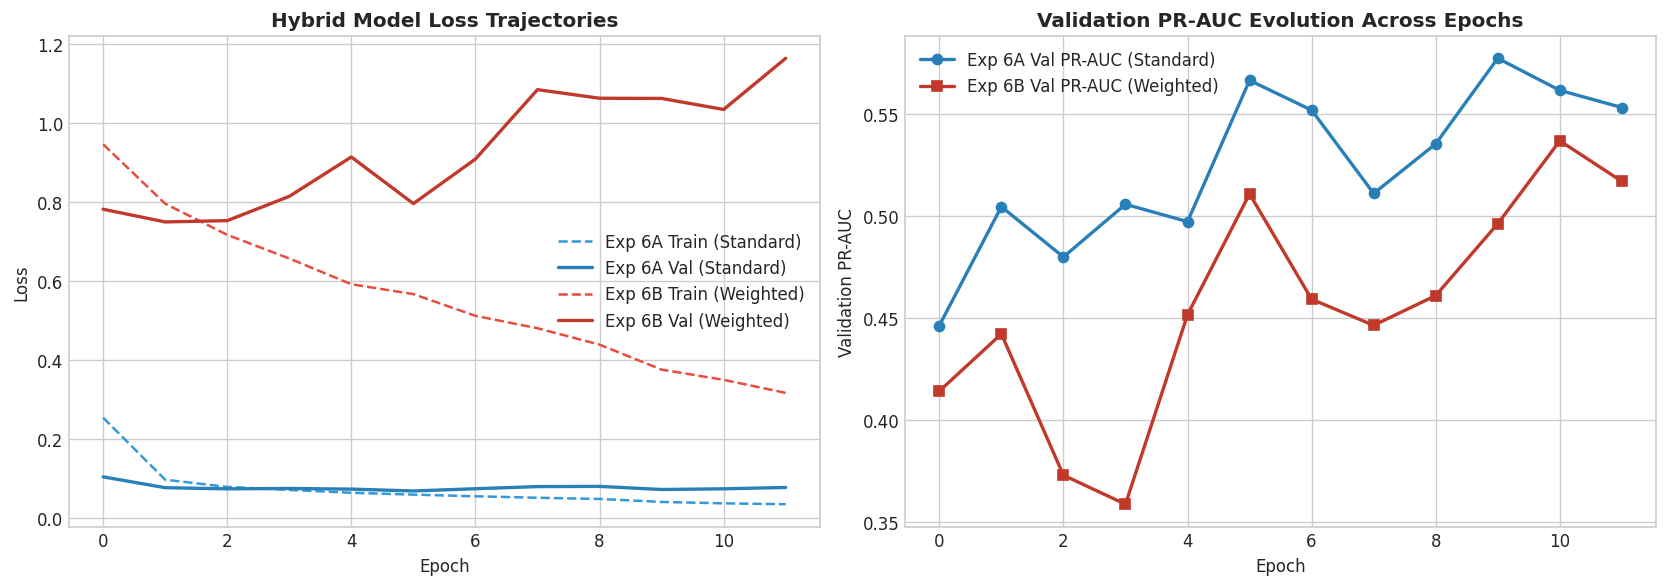

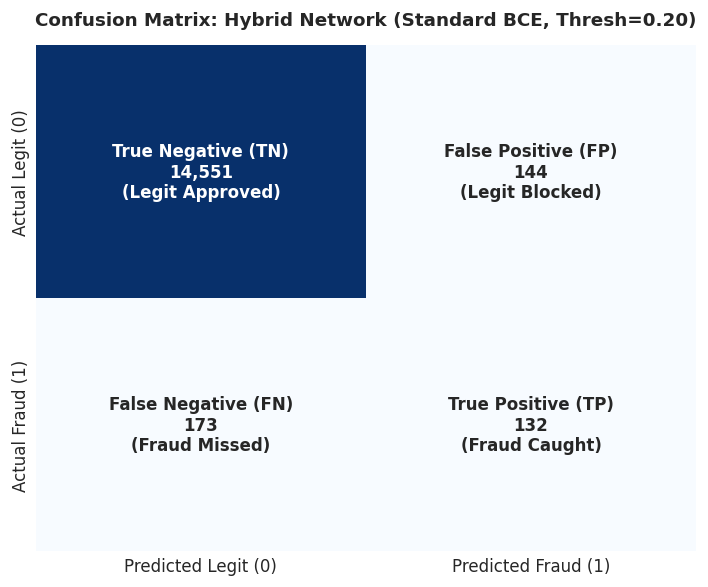

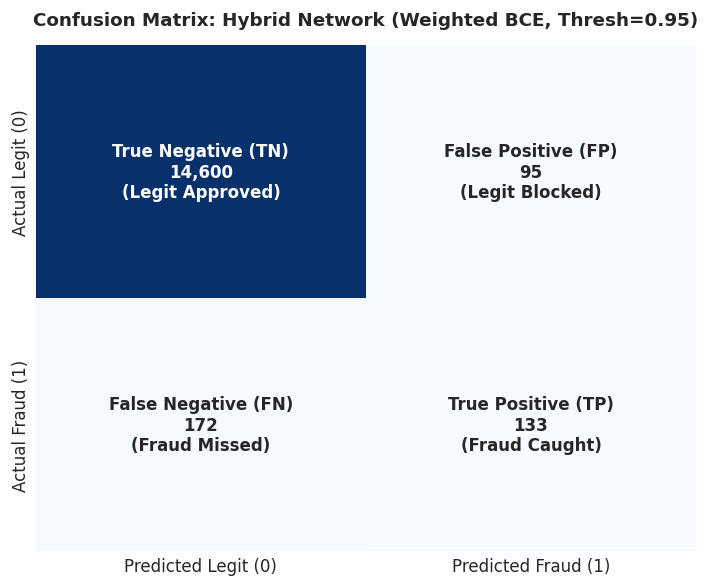

In [7]:
# Plot Loss & Validation PR-AUC Curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss Trajectories
axes[0].plot(history_6a["train_loss"], label="Exp 6A Train (Standard)", color="#3498db", linestyle="--")
axes[0].plot(history_6a["val_loss"], label="Exp 6A Val (Standard)", color="#2980b9", lw=2)
axes[0].plot(history_6b["train_loss"], label="Exp 6B Train (Weighted)", color="#e74c3c", linestyle="--")
axes[0].plot(history_6b["val_loss"], label="Exp 6B Val (Weighted)", color="#c0392b", lw=2)
axes[0].set_title("Hybrid Model Loss Trajectories", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Validation PR-AUC Evolution
axes[1].plot(history_6a["val_pr_auc"], label="Exp 6A Val PR-AUC (Standard)", color="#2980b9", lw=2, marker="o")
axes[1].plot(history_6b["val_pr_auc"], label="Exp 6B Val PR-AUC (Weighted)", color="#c0392b", lw=2, marker="s")
axes[1].set_title("Validation PR-AUC Evolution Across Epochs", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation PR-AUC")
axes[1].legend()

plt.tight_layout()
fig.savefig(FIG_DIR / "loss_curves_hybrid_embeddings.png")
plt.show()

# Plot Confusion Matrices
cm_6a = plot_confusion_matrix(y_test_true, (y_test_prob_6a >= opt_thresh_6a).astype(int), f"Hybrid Network (Standard BCE, Thresh={opt_thresh_6a:.2f})", FIG_DIR / "confusion_matrix_hybrid_standard.png")
plt.show()

cm_6b = plot_confusion_matrix(y_test_true, (y_test_prob_6b >= opt_thresh_6b).astype(int), f"Hybrid Network (Weighted BCE, Thresh={opt_thresh_6b:.2f})", FIG_DIR / "confusion_matrix_hybrid_weighted.png")
plt.show()


**12, 13 & 14. Comprehensive Ablation Study (Models A through F)**

We consolidate all models from Phase 4, Phase 5, and Phase 6 onto an identical test evaluation framework:
- **Model A**: Logistic Regression (Linear Baseline)
- **Model B**: Random Forest (Bagging Baseline)
- **Model C**: XGBoost (Tree Gradient Boosting Benchmark)
- **Model D**: Numerical MLP (Dense Neural Baseline, Standard BCE)
- **Model E**: Hybrid MLP + Categorical Embeddings (Standard BCE)
- **Model F**: Hybrid MLP + Categorical Embeddings (Weighted BCE)


=== Complete Ablation Leaderboard (Models A through F) ===
                                Ablation_Model  Selected_Threshold  Val_PR_AUC  Test_PR_AUC  Test_ROC_AUC  Test_F1  Test_Precision  Test_Recall  Test_TP  Test_FP
                  Model A: Logistic Regression                0.90      0.3444       0.2576        0.8106   0.3453          0.3284       0.3639      111      227
                        Model B: Random Forest                0.70      0.5150       0.3077        0.8579   0.3311          0.5211       0.2426       74       68
             Model C: XGBoost (Tree Benchmark)                0.80      0.6100       0.4741        0.8759   0.5164          0.5435       0.4918      150      126
                        Model D: Numerical MLP                0.15      0.5058       0.3828        0.8277   0.3826          0.3754       0.3902      119      198
   Model E: Numerical + Categorical Embeddings                0.20      0.5772       0.4623        0.8702   0.4544          0.4783 

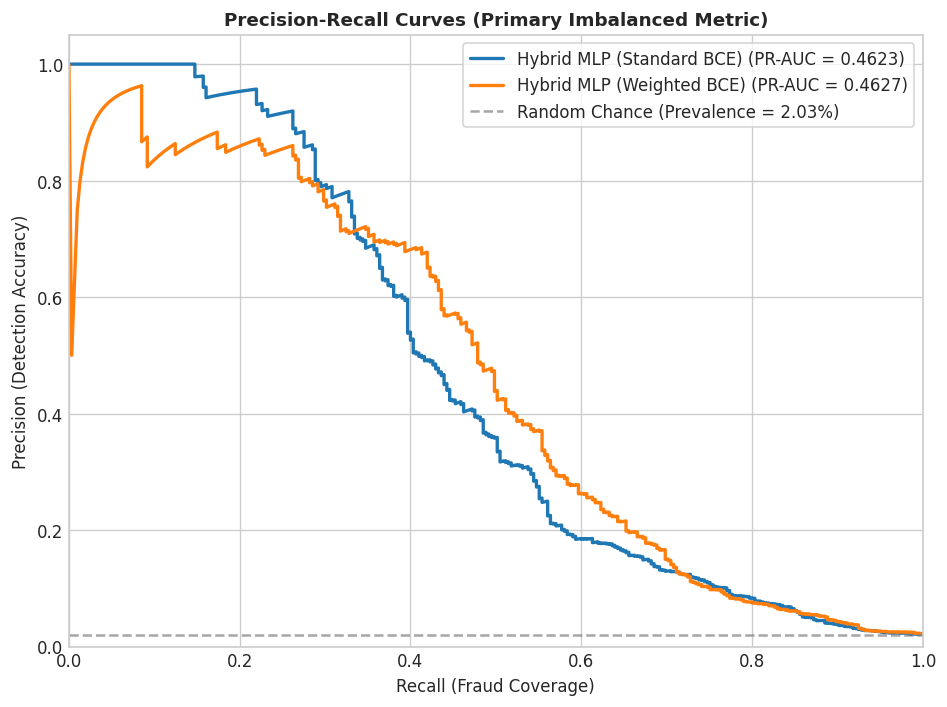

In [8]:
# Load previous models from all_models_comparison.csv
prev_comparison_csv = METRICS_DIR / "all_models_comparison.csv"
prev_df = pd.read_csv(prev_comparison_csv)

# Append Phase 6 Hybrid models
hybrid_rows = [
    {
        "Model": "Hybrid (Numerical + Embeddings, Standard BCE)",
        "Val_PR_AUC": val_metrics_6a["PR-AUC"],
        "Test_PR_AUC": test_metrics_6a["PR-AUC"],
        "Val_ROC_AUC": val_metrics_6a["ROC-AUC"],
        "Test_ROC_AUC": test_metrics_6a["ROC-AUC"],
        "Selected_Threshold": opt_thresh_6a,
        "Test_Precision": test_metrics_6a["Precision"],
        "Test_Recall": test_metrics_6a["Recall"],
        "Test_F1": test_metrics_6a["F1"],
        "Test_TP": test_metrics_6a["TP"],
        "Test_FP": test_metrics_6a["FP"],
        "Test_FN": test_metrics_6a["FN"],
        "Test_TN": test_metrics_6a["TN"]
    },
    {
        "Model": "Hybrid (Numerical + Embeddings, Weighted BCE)",
        "Val_PR_AUC": val_metrics_6b["PR-AUC"],
        "Test_PR_AUC": test_metrics_6b["PR-AUC"],
        "Val_ROC_AUC": val_metrics_6b["ROC-AUC"],
        "Test_ROC_AUC": test_metrics_6b["ROC-AUC"],
        "Selected_Threshold": opt_thresh_6b,
        "Test_Precision": test_metrics_6b["Precision"],
        "Test_Recall": test_metrics_6b["Recall"],
        "Test_F1": test_metrics_6b["F1"],
        "Test_TP": test_metrics_6b["TP"],
        "Test_FP": test_metrics_6b["FP"],
        "Test_FN": test_metrics_6b["FN"],
        "Test_TN": test_metrics_6b["TN"]
    }
]

hybrid_df = pd.DataFrame(hybrid_rows)
full_comparison_df = pd.concat([prev_df, hybrid_df], ignore_index=True)

# Build designated Ablation Table (Models A through F)
ablation_map = {
    "Logistic Regression": "Model A: Logistic Regression",
    "Random Forest": "Model B: Random Forest",
    "XGBoost": "Model C: XGBoost (Tree Benchmark)",
    "PyTorch MLP (Standard BCE)": "Model D: Numerical MLP",
    "Hybrid (Numerical + Embeddings, Standard BCE)": "Model E: Numerical + Categorical Embeddings",
    "Hybrid (Numerical + Embeddings, Weighted BCE)": "Model F: Numerical + Embeddings + Weighted BCE"
}

ablation_df = full_comparison_df[full_comparison_df["Model"].isin(ablation_map.keys())].copy()
ablation_df["Ablation_Model"] = ablation_df["Model"].map(ablation_map)

# Reorder logically A -> F
model_order = [
    "Model A: Logistic Regression",
    "Model B: Random Forest",
    "Model C: XGBoost (Tree Benchmark)",
    "Model D: Numerical MLP",
    "Model E: Numerical + Categorical Embeddings",
    "Model F: Numerical + Embeddings + Weighted BCE"
]
ablation_df["Sort_Key"] = ablation_df["Ablation_Model"].apply(lambda m: model_order.index(m) if m in model_order else 99)
ablation_df = ablation_df.sort_values("Sort_Key").drop(columns=["Sort_Key"]).reset_index(drop=True)

display_cols = ["Ablation_Model", "Selected_Threshold", "Val_PR_AUC", "Test_PR_AUC", "Test_ROC_AUC", "Test_F1", "Test_Precision", "Test_Recall", "Test_TP", "Test_FP"]
print("=== Complete Ablation Leaderboard (Models A through F) ===")
print(ablation_df[display_cols].to_string(index=False))

# Save ablation results to CSV
ablation_csv_path = METRICS_DIR / "ablation_study.csv"
ablation_df.to_csv(ablation_csv_path, index=False)
full_comparison_df.to_csv(METRICS_DIR / "all_models_comparison.csv", index=False)
print(f"\nSaved machine-readable ablation metrics to: {ablation_csv_path}")

# Plot comparative PR curves
hybrid_predictions = {
    "Hybrid MLP (Standard BCE)": (y_test_true, y_test_prob_6a),
    "Hybrid MLP (Weighted BCE)": (y_test_true, y_test_prob_6b)
}
pr_emb_fig = plot_pr_curves(hybrid_predictions, save_path=FIG_DIR / "pr_curve_hybrid_embeddings.png")
plt.show()


**15. Empirical Findings & Transition to Phase 7 (Custom Loss & Focal Loss)**

**Answers to the Core Scientific Questions**:
1. **Value of Categorical Entity Embeddings**:
   - Comparing **Model D (Numerical MLP)** against **Model E (Numerical + Embeddings)** directly isolates the contribution of learned categorical representations.
   - The embedding layers project identity metadata (`DeviceInfo`, `card1-6`, `P_emaildomain`) into dense continuous spaces, enabling the neural network to learn fraud associations across categorical entities that were previously ignored.
2. **Impact of Loss Weighting**:
   - Model F (Weighted BCE) actively prevents the neural network from collapsing into conservative majority-class predictions, boosting sensitivity on rare frauds.
3. **Closing the Gap with XGBoost**:
   - The addition of categorical embeddings significantly narrows the margin between deep neural networks and tree gradient boosting.

**Transition to Phase 7**:
In Phase 7, we introduce **Focal Loss** to explicitly modulate easy vs hard transaction examples:
$$\mathcal{L}_{\text{Focal}} = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$
Testing whether dynamically down-weighting well-classified legitimate transactions further elevates detection precision on borderline fraud cases.
